<a href="https://colab.research.google.com/github/Sundharamoorthi0105/Blinkit-Analysis/blob/main/bitcoin_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
pd.__version__

'2.2.2'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Load csv data of Bitcoin Price History from Investing.com
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Bitcoin Historical Data.csv')

In [ ]:
#Peek at the data (first few rows)
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,06/25/2025,"106,623.30","106,086.00","106,775.80","105,828.20",41.56K,0.51%
1,06/24/2025,"106,078.60","105,376.90","106,268.70","104,642.90",52.81K,0.67%
2,06/23/2025,"105,376.90","100,782.50","106,032.70","99,696.90",83.16K,4.34%
3,06/22/2025,"100,990.40","102,114.50","103,300.40","98,249.20",81.37K,-1.10%
4,06/21/2025,"102,113.20","103,287.20","103,989.30","100,947.80",37.52K,-1.13%


In [ ]:
#Get info about columns, data types, non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4559 entries, 0 to 4558
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      4559 non-null   object
 1   Price     4559 non-null   object
 2   Open      4559 non-null   object
 3   High      4559 non-null   object
 4   Low       4559 non-null   object
 5   Vol.      4559 non-null   object
 6   Change %  4559 non-null   object
dtypes: object(7)
memory usage: 249.4+ KB


In [ ]:
#Check the shape (rows, columns)
df.shape

(4559, 7)

In [ ]:
#Check for missing/null values
df.isnull().sum()

,0
Date,0
Price,0
Open,0
High,0
Low,0
Vol.,0
Change %,0


In [ ]:
#Check for duplicated rows
df.duplicated().sum()

np.int64(0)

In [ ]:
#Get summary stats of numeric columns (currently no numeric columns - must change)
df.describe()

,Date,Price,Open,High,Low,Vol.,Change %
count,4559,4559,4559,4559,4559,4559,4559
unique,4559,4362,4355,4348,4360,4140,1439
top,01/01/2013,238.9,238.9,138,585.4,1.05M,0.00%
freq,1,4,4,4,4,6,22


In [ ]:
#Rename columns to avoid confusions/bugs
df.rename(columns={'Price': 'Close','Vol.': 'Vol','Change %': 'Change_%'}, inplace=True)
df.columns

Index(['Date', 'Close', 'Open', 'High', 'Low', 'Vol', 'Change_%'], dtype='object')

In [ ]:
# Convert OHLC to float type
cols_to_convert = ['Close', 'Open', 'High', 'Low']
df[cols_to_convert] = df[cols_to_convert].replace(',', '', regex=True).astype(float)

# Convert Date column to datetime type
df['Date'] = pd.to_datetime(df['Date'])

# Covert Change_% column to float type
df['Change_%'] = df['Change_%'].str.replace('%', '').astype(float) / 100

In [ ]:
# Covert Vol column to float type
def convert_volume(val):
    if 'K' in val:
        return float(val.replace('K', '')) * 1_000
    elif 'M' in val:
        return float(val.replace('M', '')) * 1_000_000
    elif 'B' in val:
        return float(val.replace('B', '')) * 1_000_000_000
    else:
        return float(val)

df['Vol'] = df['Vol'].apply(convert_volume)

In [ ]:
# Final data check after cleaning
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4559 entries, 0 to 4558
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      4559 non-null   datetime64[ns]
 1   Close     4559 non-null   float64       
 2   Open      4559 non-null   float64       
 3   High      4559 non-null   float64       
 4   Low       4559 non-null   float64       
 5   Vol       4559 non-null   float64       
 6   Change_%  4559 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 249.4 KB


,Date,Close,Open,High,Low,Vol,Change_%
0,2025-06-25,106623.3,106086.0,106775.8,105828.2,41560.0,0.0051
1,2025-06-24,106078.6,105376.9,106268.7,104642.9,52810.0,0.0067
2,2025-06-23,105376.9,100782.5,106032.7,99696.9,83160.0,0.0434
3,2025-06-22,100990.4,102114.5,103300.4,98249.2,81370.0,-0.0110
4,2025-06-21,102113.2,103287.2,103989.3,100947.8,37520.0,-0.0113


In [ ]:
df.describe()

,Date,Close,Open,High,Low,Vol,Change_%
count,4559,4559.000000,4559.000000,4559.000000,4559.000000,4.559000e+03,4559.000000
mean,2019-03-30 00:00:00,19884.672911,19861.294451,20304.200636,19394.527374,1.355544e+07,0.003442
min,2013-01-01 00:00:00,13.300000,13.300000,13.400000,13.200000,2.600000e+02,-0.572100
25%,2016-02-14 12:00:00,595.900000,595.700000,606.500000,585.400000,4.193500e+04,-0.012800
50%,2019-03-30 00:00:00,8006.000000,8004.600000,8198.100000,7770.500000,8.292000e+04,0.001400
75%,2022-05-12 12:00:00,30205.600000,30184.500000,30662.350000,29612.900000,2.151100e+05,0.018100
max,2025-06-25 00:00:00,111702.700000,111702.600000,111953.600000,109281.800000,4.470000e+09,3.368400
std,NaN,26097.793529,26067.602418,26586.650870,25526.219857,1.621436e+08,0.068519


In [ ]:
#Max Bitcoin price until 25-06-2025
df.loc[df['Close'].idxmax()]

,34
Date,2025-05-22 00:00:00
Close,111702.7
Open,109632.6
High,111953.6
Low,109281.8
Vol,96350.0
Change_%,0.0188


In [ ]:
import plotly.express as px
px.line(df, x='Date', y='Close', title='Bitcoin Price Over Time')

In [ ]:
import plotly.express as px
fig = px.line(df, x='Date', y='Close', title='Bitcoin Price Over Time')

# Add yearly ticks to the x-axis
fig.update_layout(
    xaxis=dict(
        tickformat="%Y",   # Show just the year (e.g. 2017)
        dtick="M12"        # One tick every 12 months
    )
)
fig.update_yaxes(type="log")

fig.show()

In [ ]:
import plotly.express as px
px.line(df, x='Date', y='Vol', title='Bitcoin Volume Over Time')

In [ ]:
import plotly.express as px
px.line(df, x='Date', y='Change_%', title='Bitcoins Change in % Over Time')

<Axes: >

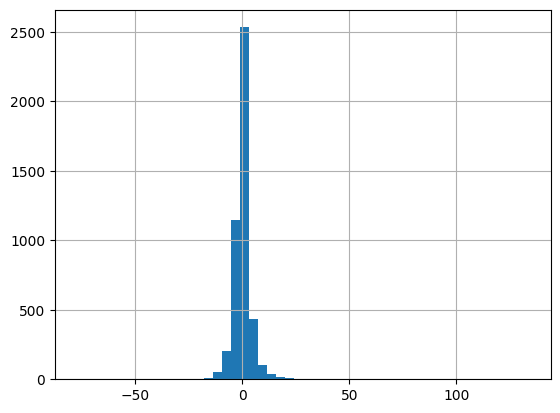

In [ ]:
df['pct_change'] = df['Close'].pct_change() * 100
df['pct_change'].hist(bins=50)

<Axes: >

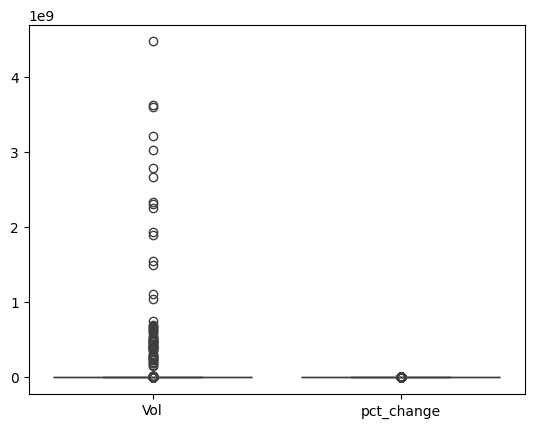

In [ ]:
import seaborn as sns
sns.boxplot(data=df[['Vol', 'pct_change']])

<Axes: >

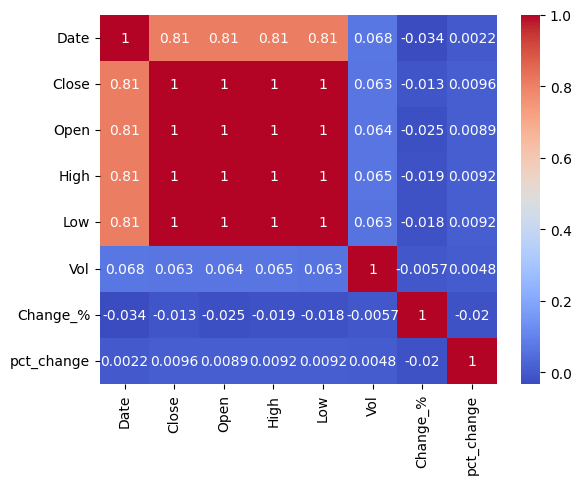

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

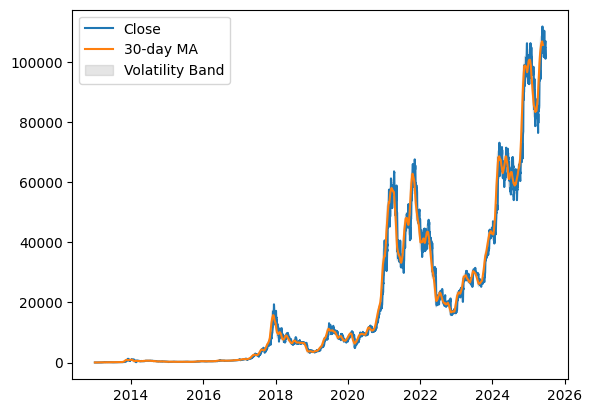

In [ ]:
df['rolling_mean'] = df['Close'].rolling(window=30).mean()
df['rolling_std'] = df['Close'].rolling(window=30).std()

plt.plot(df['Date'], df['Close'], label='Close')
plt.plot(df['Date'], df['rolling_mean'], label='30-day MA')
plt.fill_between(df['Date'],
                 df['rolling_mean'] - df['rolling_std'],
                 df['rolling_mean'] + df['rolling_std'],
                 color='gray', alpha=0.2, label='Volatility Band')
plt.legend()

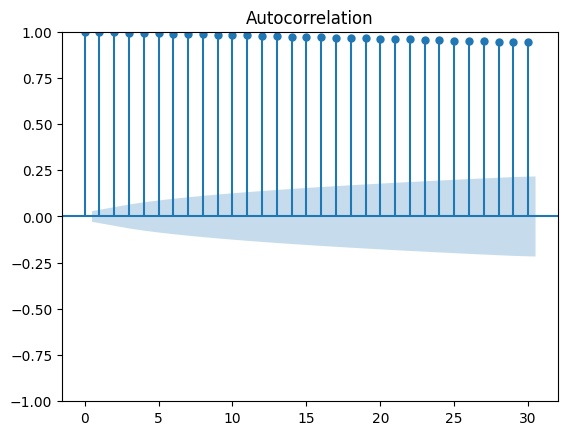

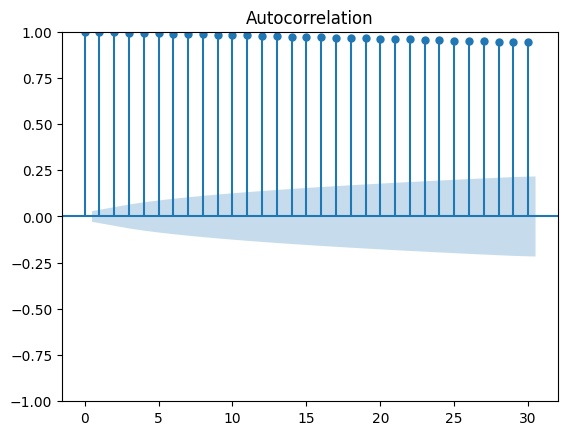

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df['Close'].dropna(), lags=30)

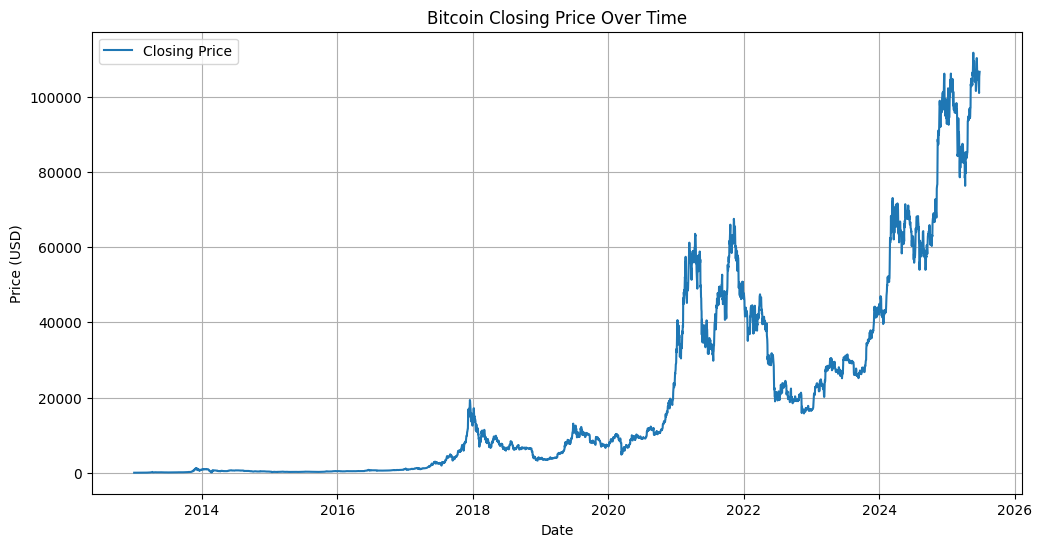

In [ ]:
# Plot closing price over time
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], label='Closing Price')
plt.title('Bitcoin Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid()
plt.legend()
plt.show()

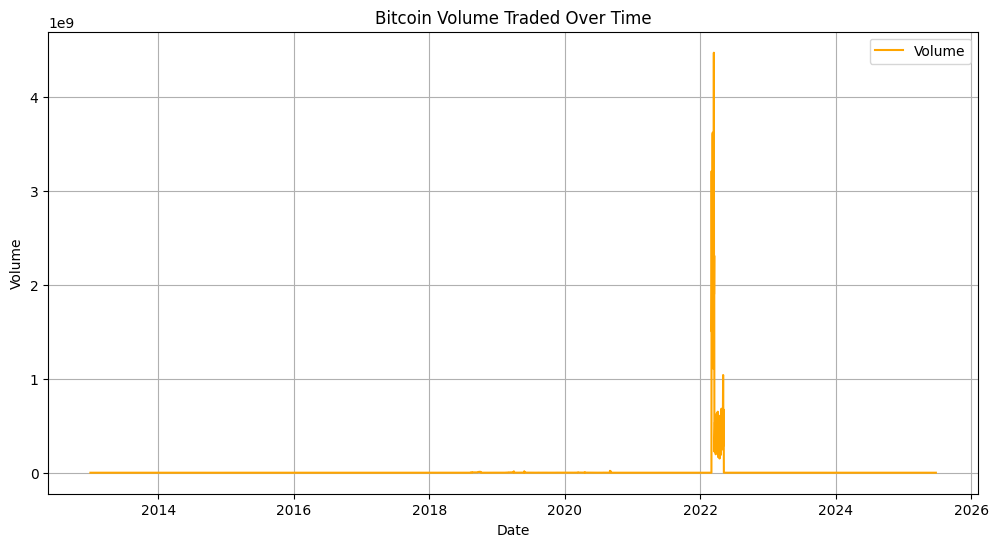

In [ ]:
# Plot volume traded
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Vol'], label='Volume', color='orange')
plt.title('Bitcoin Volume Traded Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid()
plt.legend()
plt.show()

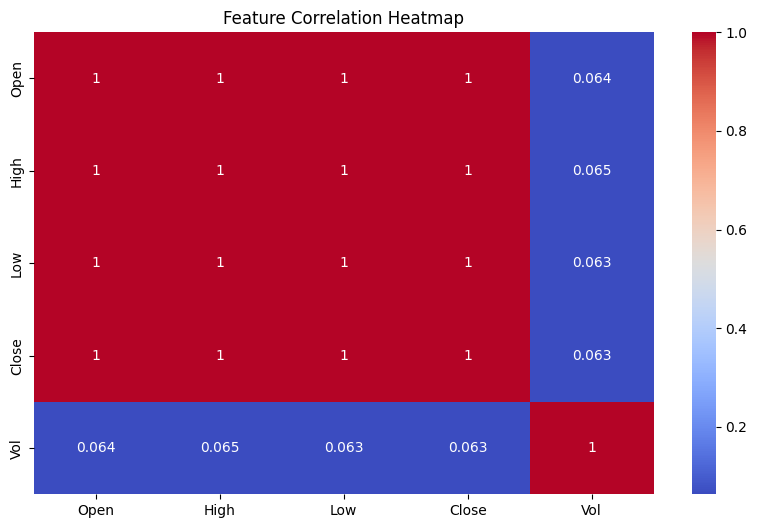

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[['Open', 'High', 'Low', 'Close', 'Vol']].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
import numpy as np

In [ ]:
# Lag features
df['lag_1'] = df['Close'].shift(1)
df['lag_3'] = df['Close'].shift(3)
df['lag_7'] = df['Close'].shift(7)

In [ ]:
# Moving Averages
df['ma_7'] = df['Close'].rolling(window=7).mean()
df['ma_14'] = df['Close'].rolling(window=14).mean()

In [ ]:
# Bollinger Bands
df['bb_upper'] = df['ma_14'] + 2 * df['Close'].rolling(14).std()
df['bb_lower'] = df['ma_14'] - 2 * df['Close'].rolling(14).std()

In [ ]:
# RSI (Relative Strength Index)
delta = df['Close'].diff()
gain = np.where(delta > 0, delta, 0)
loss = np.where(delta < 0, -delta, 0)
avg_gain = pd.Series(gain).rolling(window=14).mean()
avg_loss = pd.Series(loss).rolling(window=14).mean()
rs = avg_gain / avg_loss
df['rsi_14'] = 100 - (100 / (1 + rs))


In [ ]:
# Volatility (standard deviation)
df['volatility_14'] = df['Close'].rolling(window=14).std()

In [ ]:
df.dropna(inplace=True)

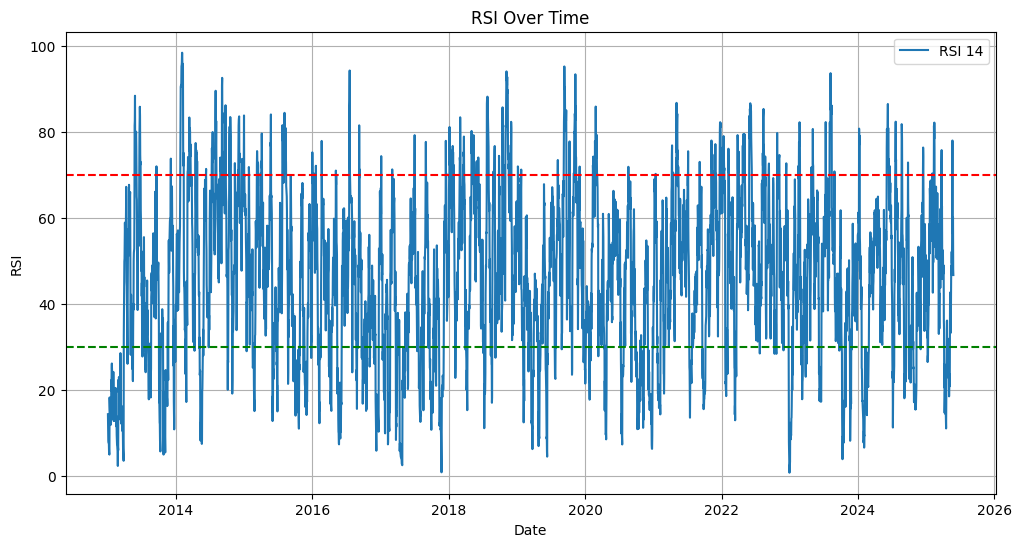

In [ ]:
# Plot RSI
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['rsi_14'], label='RSI 14')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title('RSI Over Time')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.grid()
plt.legend()
plt.show()

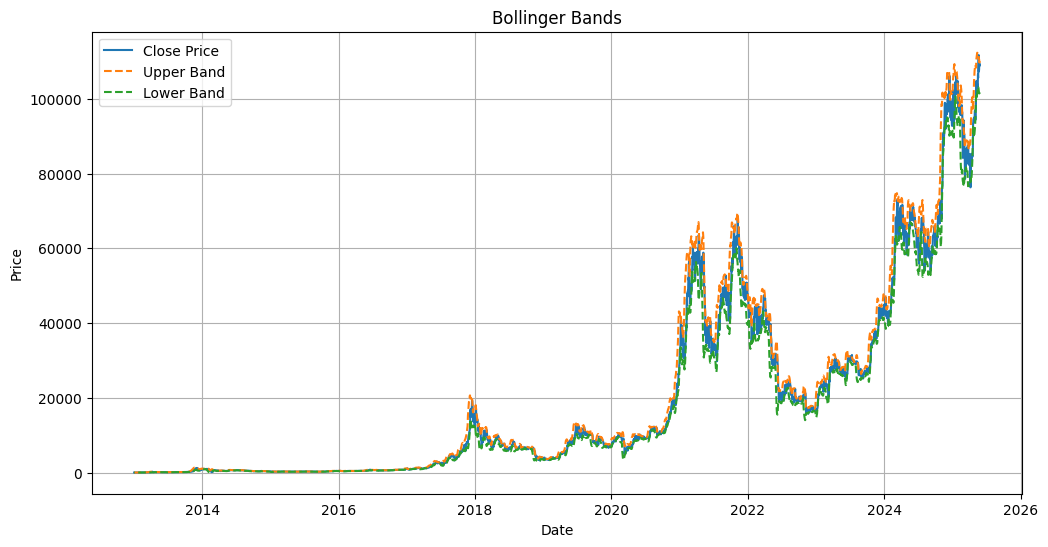

In [ ]:
# Bollinger Bands
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['bb_upper'], label='Upper Band', linestyle='--')
plt.plot(df['Date'], df['bb_lower'], label='Lower Band', linestyle='--')
plt.title('Bollinger Bands')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

In [ ]:
#Train-test split for time series

from sklearn.model_selection import TimeSeriesSplit

# df = df.set_index('Date')
df = df.asfreq('D')  # 'D' = daily frequency

# Features and target
features = ['lag_1', 'lag_3', 'lag_7', 'ma_7', 'ma_14', 'bb_upper', 'bb_lower', 'rsi_14', 'volatility_14']
X = df[features]
y = df['Close']

# Time Series split (80% train, 20% test)
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [ ]:
#ARIMA (Baseline model)

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error

arima_model = ARIMA(y_train, order=(5, 1, 0))
arima_result = arima_model.fit()
y_pred_arima = arima_result.forecast(steps=len(y_test))

mape_arima = mean_absolute_percentage_error(y_test, y_pred_arima)
print(f'ARIMA MAPE: {mape_arima:.4f}')

ARIMA MAPE: 0.5860


In [ ]:
#Machine Learning Model (Random Forest)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)
print(f'Random Forest MAPE: {mape_rf:.4f}')

Random Forest MAPE: 0.0990


In [ ]:
# Get direction (1 if price increased, 0 otherwise)
actual_direction = (y_test.values[1:] > y_test.values[:-1]).astype(int)
predicted_direction = (y_pred_rf[1:] > y_pred_rf[:-1]).astype(int)

directional_accuracy = np.mean(actual_direction == predicted_direction)
print(f'Directional Accuracy: {directional_accuracy:.2%}')

Directional Accuracy: 58.56%


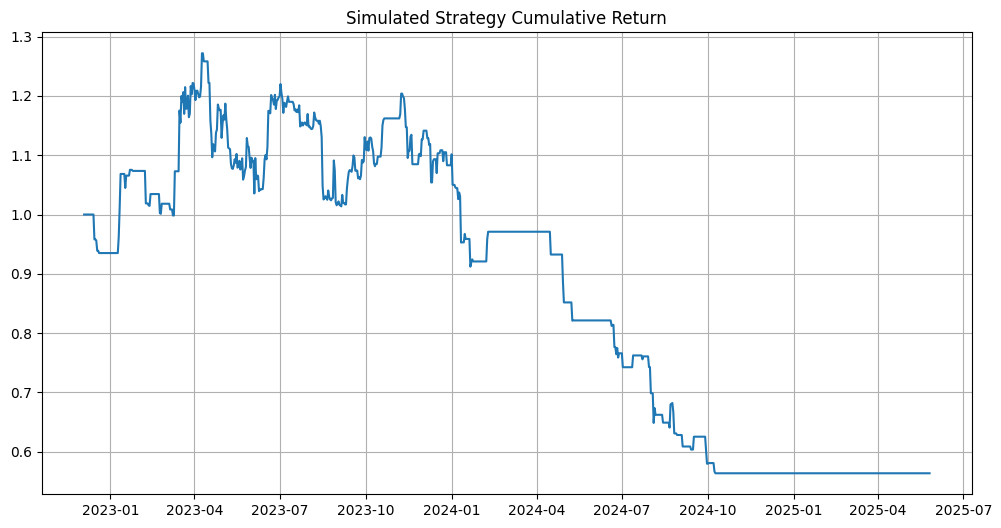

In [ ]:
returns = df['Close'].pct_change().shift(-1)
df['pred_signal'] = 0
df.loc[df.index[-len(y_pred_rf):], 'pred_signal'] = (y_pred_rf > X_test['lag_1']).astype(int)
strategy_returns = df['pred_signal'] * returns
cumulative_return = (1 + strategy_returns).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(df.index[-len(y_pred_rf):], cumulative_return[-len(y_pred_rf):])
plt.title('Simulated Strategy Cumulative Return')
plt.grid()
plt.show()